In [13]:
import pandas as pd
import ast
from paretoset import paretoset
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

In [2]:
name = 'binary1'

In [3]:
deepseek_df = pd.read_csv(f'deepseekR1_ZS_{name}.csv')
gemma_df = pd.read_csv(f'gemma_ZS_{name}.csv')
llama_df = pd.read_csv(f'llama_ZS_{name}.csv')
openai_df = pd.read_csv(f'openai_ZS_{name}.csv')
gemini_df = pd.read_csv(f'gemini_ZS_{name}.csv')

sklearn_df = pd.read_csv(f'results_sklearn_{name}.csv')
bert_df = pd.read_csv(f'bert_{name}.csv')

In [4]:
size = len(deepseek_df)
size

3883

In [5]:
def results_llm(df):
    error_count = len(df[df['prediction'] == 'error'])
    error_rate = error_count / len(df)

    print(f"Total predictions: {len(df)}")
    print(f"Error count: {error_count}")
    print(f"Error rate: {error_rate:.2%}")

    try:
        df = df[df['prediction_post_processed'] != 'error']
    except:
        df = df[df['prediction'] != 'error']

    y_true = df['label']

    try:
        y_pred = df['prediction_post_processed']
    except:
        y_pred = df['prediction']
        

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    try:
        mean_ram_usage = df['ram_usage'].mean()
        mean_vram_usage = df['vram_usage'].mean()
    except:
        mean_ram_usage = 0
        mean_vram_usage = 0
    
    try:
        mean_time = df['response_time'].mean()
    except:
        mean_time = df['request_time'].mean()

    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'mean_ram_usage': mean_ram_usage,
        'mean_vram_usage': mean_vram_usage,
        'mean_response_time': mean_time
    }

    print(results)

    return results

In [6]:
print("DeepSeek results:")
results_deepseek = results_llm(deepseek_df)
print("\n")
print("Gemma results:")
results_gemma = results_llm(gemma_df)
print("\n")
print("Llama results:")
results_llama = results_llm(llama_df)
print("\n")
print("OpenAI results:")
results_openai = results_llm(openai_df)
print("\n")
print("Gemini results:")
results_gemini = results_llm(gemini_df)
print("\n")

DeepSeek results:
Total predictions: 3883
Error count: 562
Error rate: 14.47%
{'accuracy': 0.6266184884071063, 'precision': 0.6266136667863789, 'recall': 0.6265863896904256, 'f1_score': 0.6265816173302169, 'mean_ram_usage': np.float64(77.01968651196928), 'mean_vram_usage': np.float64(2442.109906654622), 'mean_response_time': np.float64(5.2732570833988985)}


Gemma results:
Total predictions: 3883
Error count: 1
Error rate: 0.03%
{'accuracy': 0.6746522411128284, 'precision': 0.7335819503677744, 'recall': 0.6745227579177594, 'f1_score': 0.6526511656244831, 'mean_ram_usage': np.float64(102.68560825605358), 'mean_vram_usage': np.float64(4855.155074703761), 'mean_response_time': np.float64(2.3607977951758303)}


Llama results:
Total predictions: 3883
Error count: 373
Error rate: 9.61%
{'accuracy': 0.6820512820512821, 'precision': 0.7117974498449808, 'recall': 0.6900271076604603, 'f1_score': 0.6758365508365508, 'mean_ram_usage': np.float64(89.09898170405982), 'mean_vram_usage': np.float64(39

In [7]:
def results_sklearn(df):
    
    grouped = df.groupby(['vectorizer', 'model', 'params'])

    df['average_f1'] = df.filter(like='f1_class_').mean(axis=1)
    df['average_precision'] = df.filter(like='precision_class_').mean(axis=1)
    df['average_recall'] = df.filter(like='recall_class_').mean(axis=1)
    
    mean_f1 = grouped['average_f1'].mean().reset_index()
    
    best_model = mean_f1.loc[mean_f1['average_f1'].idxmax()]
    
    best_config_df = df[(df['vectorizer'] == best_model['vectorizer']) &
                        (df['model'] == best_model['model']) &
                        (df['params'] == best_model['params'])]
    
    accuracy = best_config_df['accuracy'].mean()
    f1 = best_config_df['average_f1'].mean()
    precision = best_config_df['average_precision'].mean()
    recall = best_config_df['average_recall'].mean()
    mean_ram_usage = best_config_df['peak_memory_prediction'].mean()
    mean_vram_usage = 0
    pred_time = best_config_df['prediction_time'].mean()

    std_accuracy = best_config_df['accuracy'].std()
    std_f1 = best_config_df['average_f1'].std()
    std_precision = best_config_df['average_precision'].std()
    std_recall = best_config_df['average_recall'].std()
    std_ram_usage = best_config_df['peak_memory_prediction'].std()
    std_vram_usage = 0
    std_pred_time = best_config_df['prediction_time'].std()


    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'mean_ram_usage': mean_ram_usage,
        'mean_vram_usage': mean_vram_usage,
        'mean_response_time': pred_time / size
    }

    results_std = {
        'std_accuracy': std_accuracy,
        'std_precision': std_precision,
        'std_recall': std_recall,
        'std_f1_score': std_f1,
        'std_mean_ram_usage': std_ram_usage,
        'std_mean_vram_usage': std_vram_usage,
        'std_mean_response_time': std_pred_time / size
    }
    

    return results, results_std

In [8]:
results_sklearn_model = results_sklearn(sklearn_df)[0]

In [9]:
def results_bert(df):

    df['average_test_f1'] = df['test_f1s'].apply(
        lambda x: sum(ast.literal_eval(x)) / len(ast.literal_eval(x))
    )
    df['average_test_precisions'] = df['test_precisions'].apply(
        lambda x: sum(ast.literal_eval(x)) / len(ast.literal_eval(x))
    )
    df['average_test_recalls'] = df['test_recalls'].apply(
        lambda x: sum(ast.literal_eval(x)) / len(ast.literal_eval(x))
    )

    accuracy = df['test_acc'].mean()
    precision = df['average_test_precisions'].mean()
    recall = df['average_test_recalls'].mean()
    f1 = df['average_test_f1'].mean()
    mean_ram_usage = df['max_memory_usage_test'].mean()
    mean_vram_usage = df['max_vram_usage_test'].mean()
    mean_time = df['total_test_time'].mean()

    # now get standar deviation
    std_accuracy = df['test_acc'].std()
    std_precision = df['average_test_precisions'].std()
    std_recall = df['average_test_recalls'].std()
    std_f1 = df['average_test_f1'].std()
    std_ram_usage = df['max_memory_usage_test'].std()
    std_vram_usage = df['max_vram_usage_test'].std()
    std_time = df['total_test_time'].std()

    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'mean_ram_usage': mean_ram_usage,
        'mean_vram_usage': mean_vram_usage,
        'mean_response_time': mean_time / size
    }

    results_std = {
        'std_accuracy': std_accuracy,
        'std_precision': std_precision,
        'std_recall': std_recall,
        'std_f1_score': std_f1,
        'std_ram_usage': std_ram_usage,
        'std_vram_usage': std_vram_usage,
        'std_response_time': std_time / size
    }

    
    return results, results_std

results_bert_model = results_bert(bert_df)[0]
results_bert_model

{'accuracy': np.float64(0.822559876384239),
 'precision': np.float64(0.8273849329564525),
 'recall': np.float64(0.8225443228873464),
 'f1_score': np.float64(0.8218929870219825),
 'mean_ram_usage': np.float64(1154.0872395833333),
 'mean_vram_usage': np.float64(1768.3287760416667),
 'mean_response_time': np.float64(0.009916626834919)}

Models on the Pareto Frontier:
     model      time        f1
5     BERT  0.009917  0.821893
6  sklearn  0.000280  0.730692


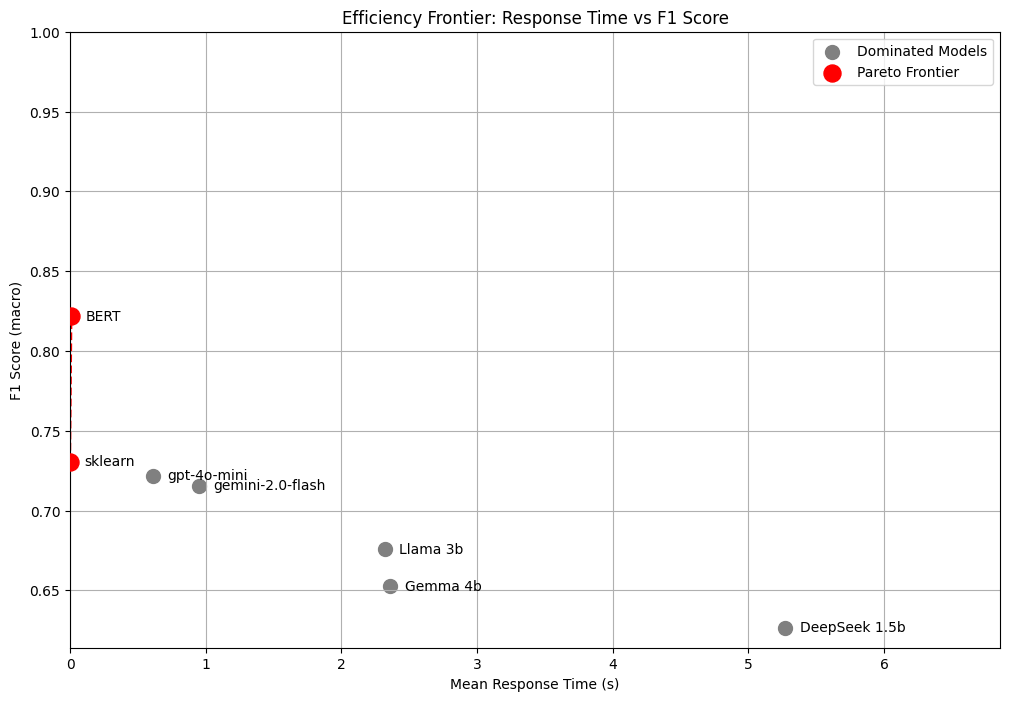

In [14]:
def plot_results(results):
    # --- Original Data Preparation ---
    models = ['DeepSeek 1.5b', 'Gemma 4b', 'Llama 3b', 'gpt-4o-mini', 'gemini-2.0-flash', 'BERT', 'sklearn']
    mean_response_times = [result['mean_response_time'] for result in results]
    f1_scores = [result['f1_score'] for result in results]

    # --- 1. Create a DataFrame for easy analysis ---
    # The paretoset library works best with pandas DataFrames.
    df = pd.DataFrame({
        'model': models,
        'time': mean_response_times,
        'f1': f1_scores
    })

    # --- 2. Calculate the Pareto Frontier ---
    # We want to MINIMIZE time and MAXIMIZE f1 score.
    # The paretoset function returns a boolean 'mask' to identify the optimal models.
    is_on_frontier = paretoset(df[['time', 'f1']], sense=['min', 'max'])
    
    # Use the mask to get a new DataFrame with only the frontier models.
    frontier_df = df[is_on_frontier]
    
    print("Models on the Pareto Frontier:")
    print(frontier_df)

    # --- 3. Plotting ---
    plt.figure(figsize=(12, 8)) # Made figure larger for better readability
    
    # Plot all models as grey points
    plt.scatter(df['time'], df['f1'], color='grey', s=100, label='Dominated Models')
    
    # Highlight the Pareto frontier models in red
    plt.scatter(frontier_df['time'], frontier_df['f1'], color='red', s=150, zorder=5, label='Pareto Frontier')
    
    # Draw a line connecting the frontier points for clarity
    # Sort the frontier points by time to draw a proper line
    frontier_df = frontier_df.sort_values(by='time')
    plt.plot(frontier_df['time'], frontier_df['f1'], 'r--')

    # Add labels to all points
    offset = (max(mean_response_times) * 0.02) # Dynamic offset
    for i, row in df.iterrows():
        plt.text(row['time'] + offset, row['f1'], row['model'], ha='left', va='center')

    # --- Formatting the plot ---
    xlim_max = max(mean_response_times)
    plt.xlim(left=0, right=xlim_max + xlim_max * 0.3)
    plt.ylim(bottom=min(f1_scores) * 0.98, top=1.0) # Adjust y-axis to focus on the F1 range
    plt.xlabel('Mean Response Time (s)')
    plt.ylabel('F1 Score (macro)')
    plt.title('Efficiency Frontier: Response Time vs F1 Score')
    plt.legend()
    plt.grid(True)
    
    plt.show()

plot_results([results_deepseek, results_gemma, results_llama, results_openai, results_gemini, results_bert_model, results_sklearn_model])

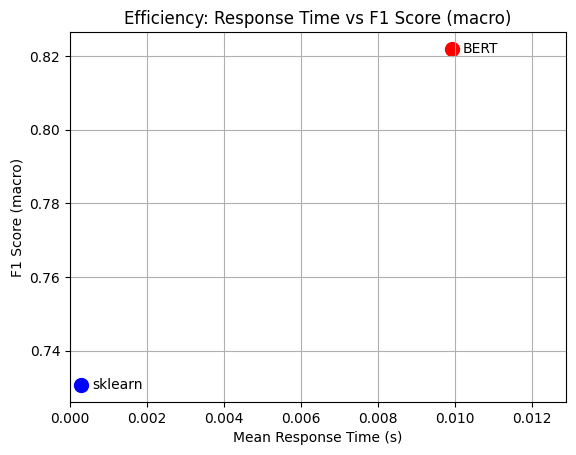

In [15]:
def plot_results(results):
    models = ['BERT', 'sklearn']
    colors = ['red', 'blue']
    
    mean_response_times = [result['mean_response_time'] for result in results]
    f1_scores = [result['f1_score'] for result in results]
    
    offset = 0.0003
    
    for i in range(len(models)):
        plt.scatter(mean_response_times[i], f1_scores[i], color=colors[i], s=100)
        plt.text(mean_response_times[i] + offset, f1_scores[i], models[i], ha='left', va='center')
    
    xlim = max(mean_response_times)

    plt.xlim(left = 0, right = xlim + xlim * 0.3)
    plt.xlabel('Mean Response Time (s)')
    plt.ylabel('F1 Score (macro)')
    plt.title('Efficiency: Response Time vs F1 Score (macro)')
    plt.grid(True)
    
    plt.show()

plot_results([results_bert_model, results_sklearn_model])